In [1]:
import omicverse as ov
import drug2cell as d2c
ov.plot_set()

2024-11-29 20:42:35.303164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-29 20:42:35.316409: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-29 20:42:35.320463: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-29 20:42:35.330747: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-29 20:42:36.022990: W tensorflow/compiler/tf2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata=ov.read('data/GC_RNA/GAS_GC_RAW_pyliger.h5ad')
adata

AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors', 'log1p', 'pyliger_info'
    obsm: 'X_gem', 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 's

In [7]:
adata.X.max()

15.946658

In [3]:
d2c.score?

Signature:
d2c.score(
    adata,
    targets=None,
    nested=False,
    categories=None,
    method='mean',
    layer=None,
    use_raw=False,
    n_bins=25,
    ctrl_size=50,
    sep=',',
)
Docstring:
Obtain per-cell scoring of gene groups of interest. Distributed with a set of 
ChEMBL drug targets that can be used immediately.

Please ensure that the gene nomenclature in your target sets is compatible with your 
``.var_names`` (or ``.raw.var_names``). The ChEMBL drug targets use HGNC (human gene 
names in line with standard cell ranger mapping output).

Adds ``.uns['drug2cell']`` to the input AnnData, a new AnnData object with the same 
observation space but with the scored gene groups as the features. The gene group 
members used to compute the scores will be listed in ``.var['genes']`` of the new 
object.

Input
-----
adata : ``AnnData``
    Using log-normalised data is recommended.
targets : ``dict`` of lists of ``str``, optional (default: ``None``)
    The gene groups to evaluat

In [4]:
d2c.score(adata, use_raw=False)

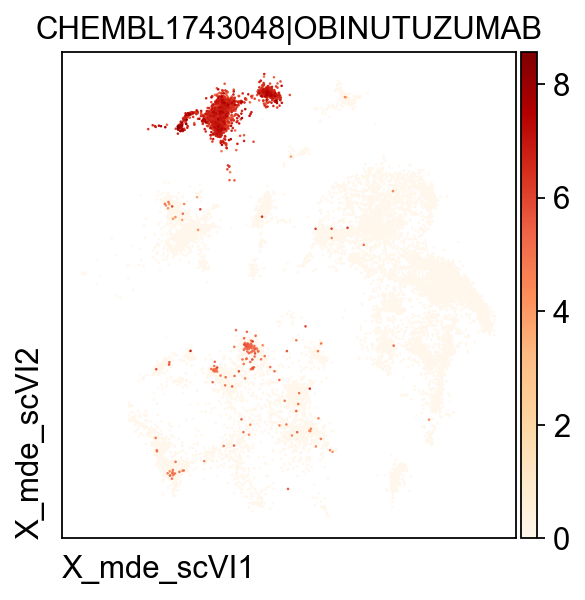

In [6]:
ov.pl.embedding(adata.uns['drug2cell'], 
                basis='X_mde_scVI',
           color="CHEMBL1743048|OBINUTUZUMAB", color_map="OrRd")


In [8]:
adata.write('data/GC_RNA/GAS_GC_RAW_drug2cell.h5ad',compression='gzip')

In [2]:
adata=ov.read('data/GC_RNA/GAS_GC_RAW_drug2cell.h5ad',compression='gzip')
adata

AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors', 'drug2cell', 'log1p', 'pyliger_info'
    obsm: 'X_gem', 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan',

In [3]:
adata_drug=adata.uns['drug2cell']
adata_drug

AnnData object with n_obs × n_vars = 22357 × 2397
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'genes', 'all_genes'
    obsm: 'X_gem', 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'

In [21]:
adata_drug.var['drug_names']=[i.split('|')[1] for i in adata_drug.var.index]
adata_drug.var['CHEMBL']=[i.split('|')[0] for i in adata_drug.var.index]
adata_drug.var.head()

,genes,all_genes,drug_names,CHEMBL
CHEMBL1615779|IOBENGUANE I 131,SLC6A2,SLC6A2,IOBENGUANE I 131,CHEMBL1615779
CHEMBL3989924|LUTETIUM DOTATATE LU-177,"SSTR1,SSTR5,SSTR2,SSTR4,SSTR3","SSTR3,SSTR2,SSTR1,SSTR5,SSTR4",LUTETIUM DOTATATE LU-177,CHEMBL3989924
CHEMBL2108709|COLLAGENASE CLOSTRIDIUM HISTOLYTICUM,"COL24A1,COL11A1,COL3A1,COL5A2,COL4A4,COL4A3,CO...","COL1A1,COL5A3,COL4A3,COL6A5,COL6A1,COL15A1,COL...",COLLAGENASE CLOSTRIDIUM HISTOLYTICUM,CHEMBL2108709
CHEMBL256997|ATALUREN,"RPL22,RPL11,RPS8,RPL5,RPS27,RPS7,RPS27A,RPL31,...","RPS24,RPS11,RPS17,RPS14,RPL9P8,RPL18A,RPS27A,R...",ATALUREN,CHEMBL256997
CHEMBL4297240|ONASEMNOGENE ABEPARVOVEC,"SMN2,SMN1","SMN1,SMN2",ONASEMNOGENE ABEPARVOVEC,CHEMBL4297240


In [22]:
adata_drug.var.index=adata_drug.var['drug_names'].tolist()

In [68]:
adata_drug.var.index=[i.replace(' ','\n') for i in adata_drug.var.index]

In [69]:
adata_drug.var_names_make_unique()

Storing dendrogram info using `.uns['dendrogram_best_celltype']`
ranking genes
    finished: added to `.uns['best_celltype_ttest']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


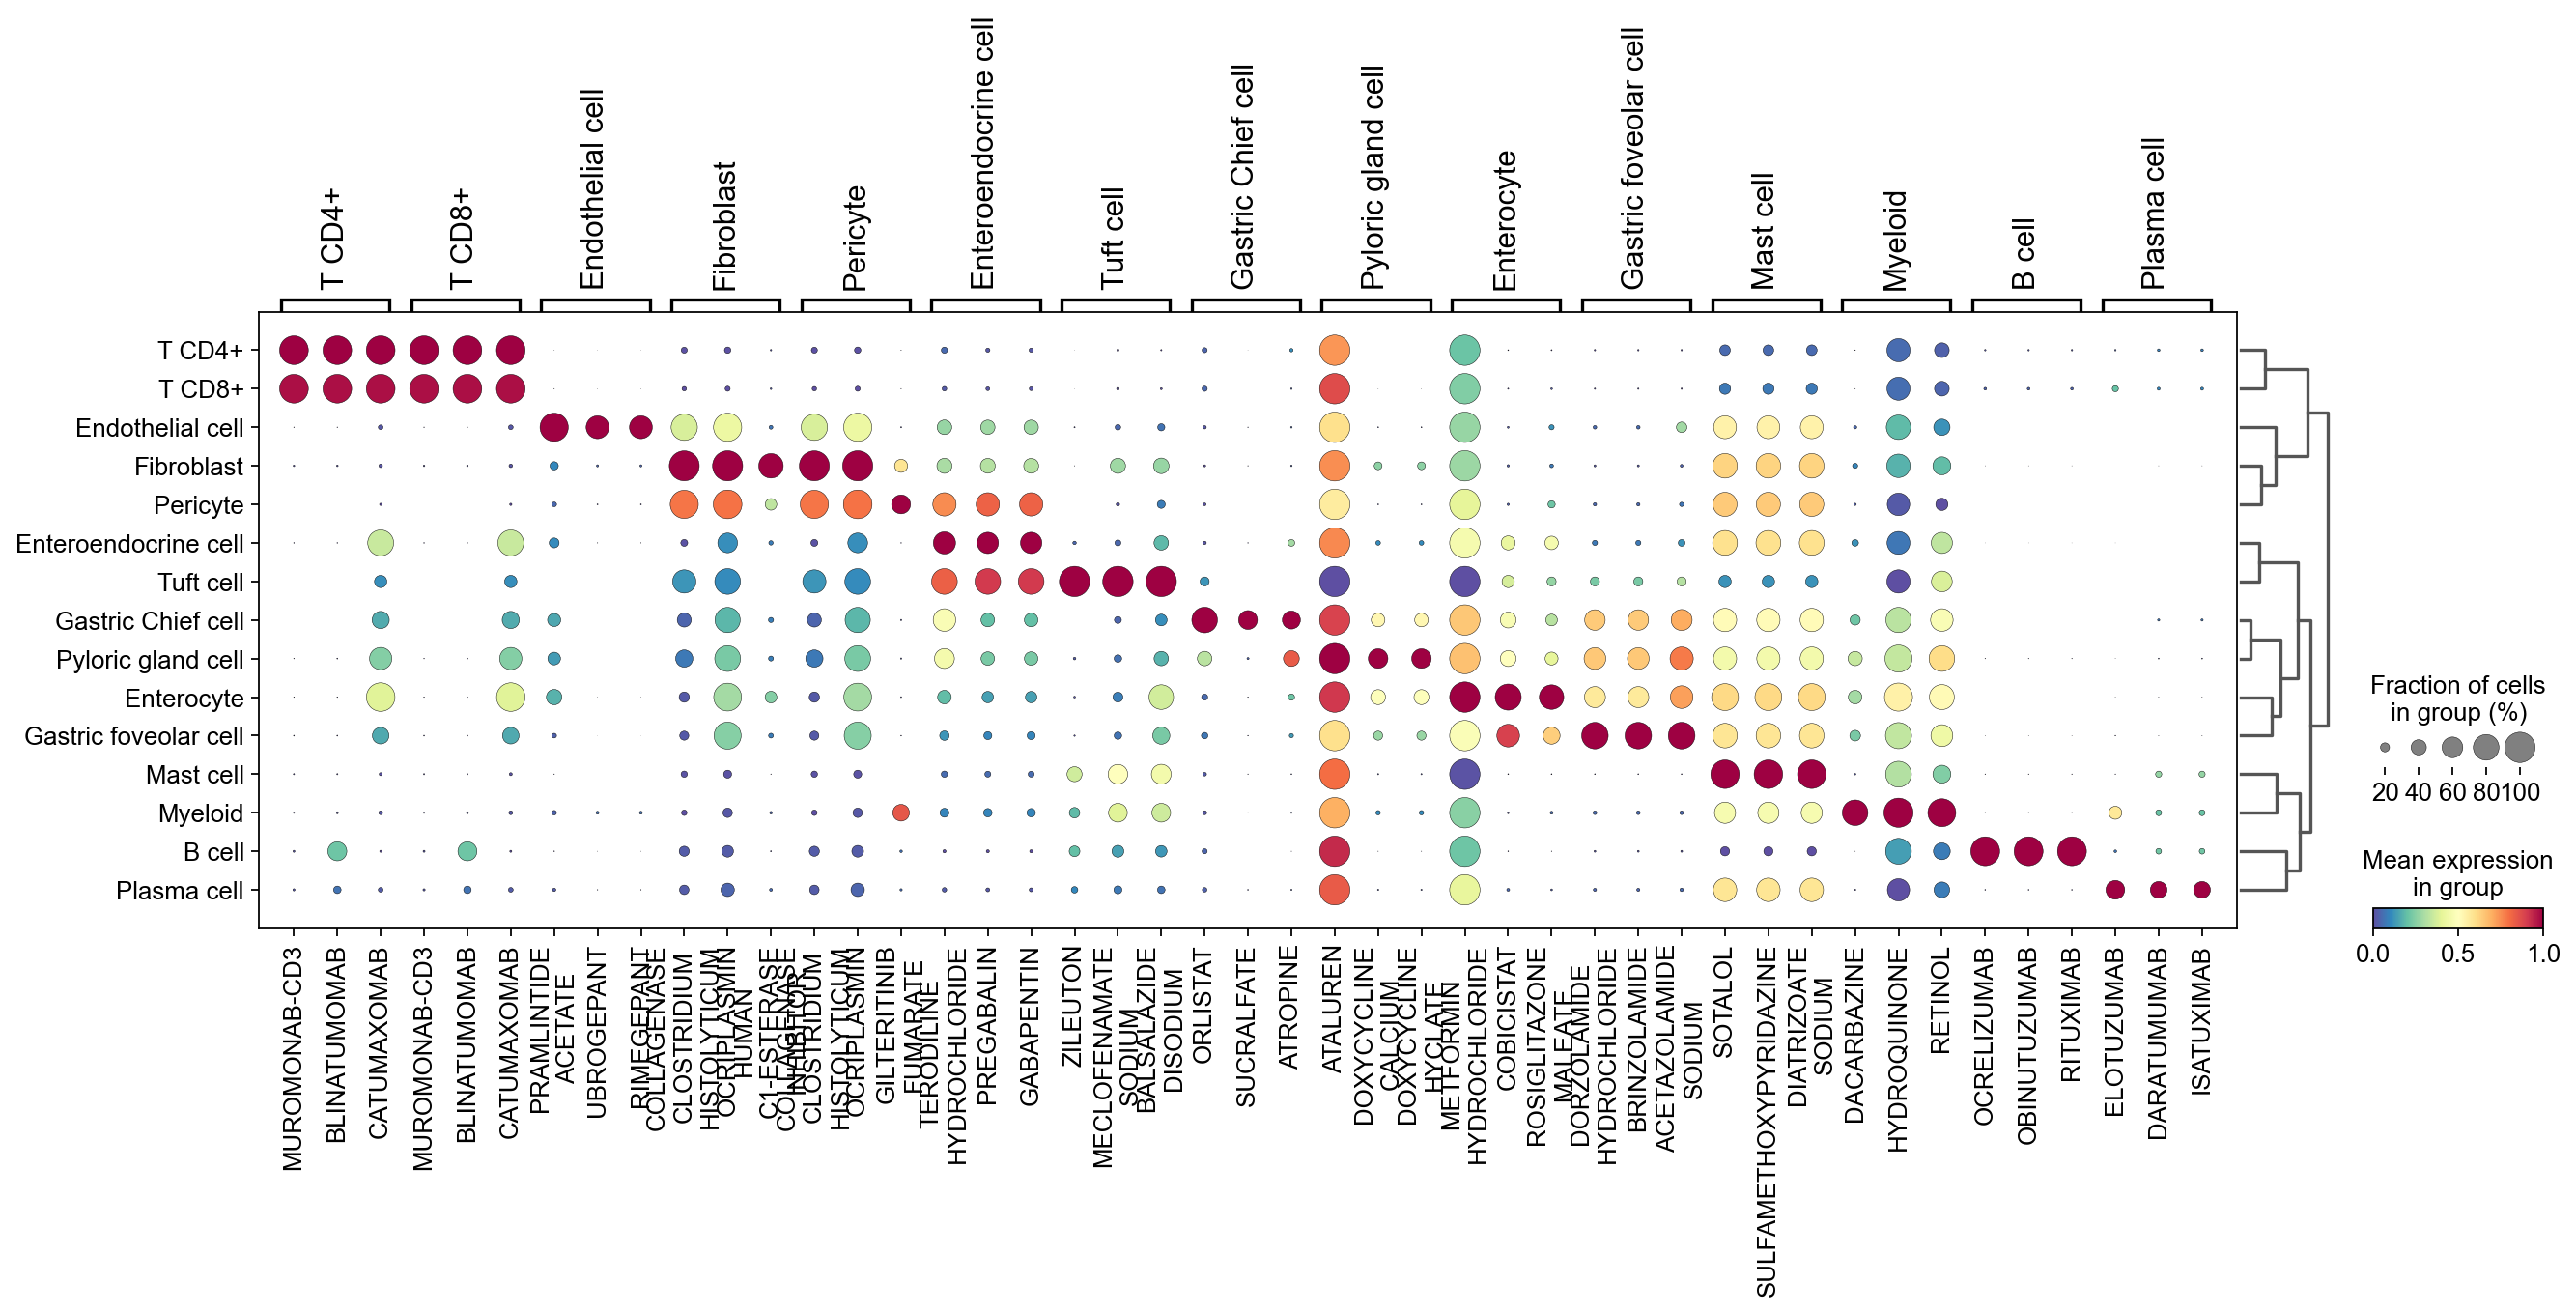

In [70]:
import scanpy as sc
sc.tl.dendrogram(adata_drug,'best_celltype',use_rep='X_scVI')
sc.tl.rank_genes_groups(adata_drug, 'best_celltype', use_rep='X_scVI',
                        method='t-test',use_raw=False,key_added='best_celltype_ttest')
sc.pl.rank_genes_groups_dotplot(adata_drug,groupby='best_celltype',
                                cmap='Spectral_r',key='best_celltype_ttest',
                                standard_scale='var',n_genes=3)

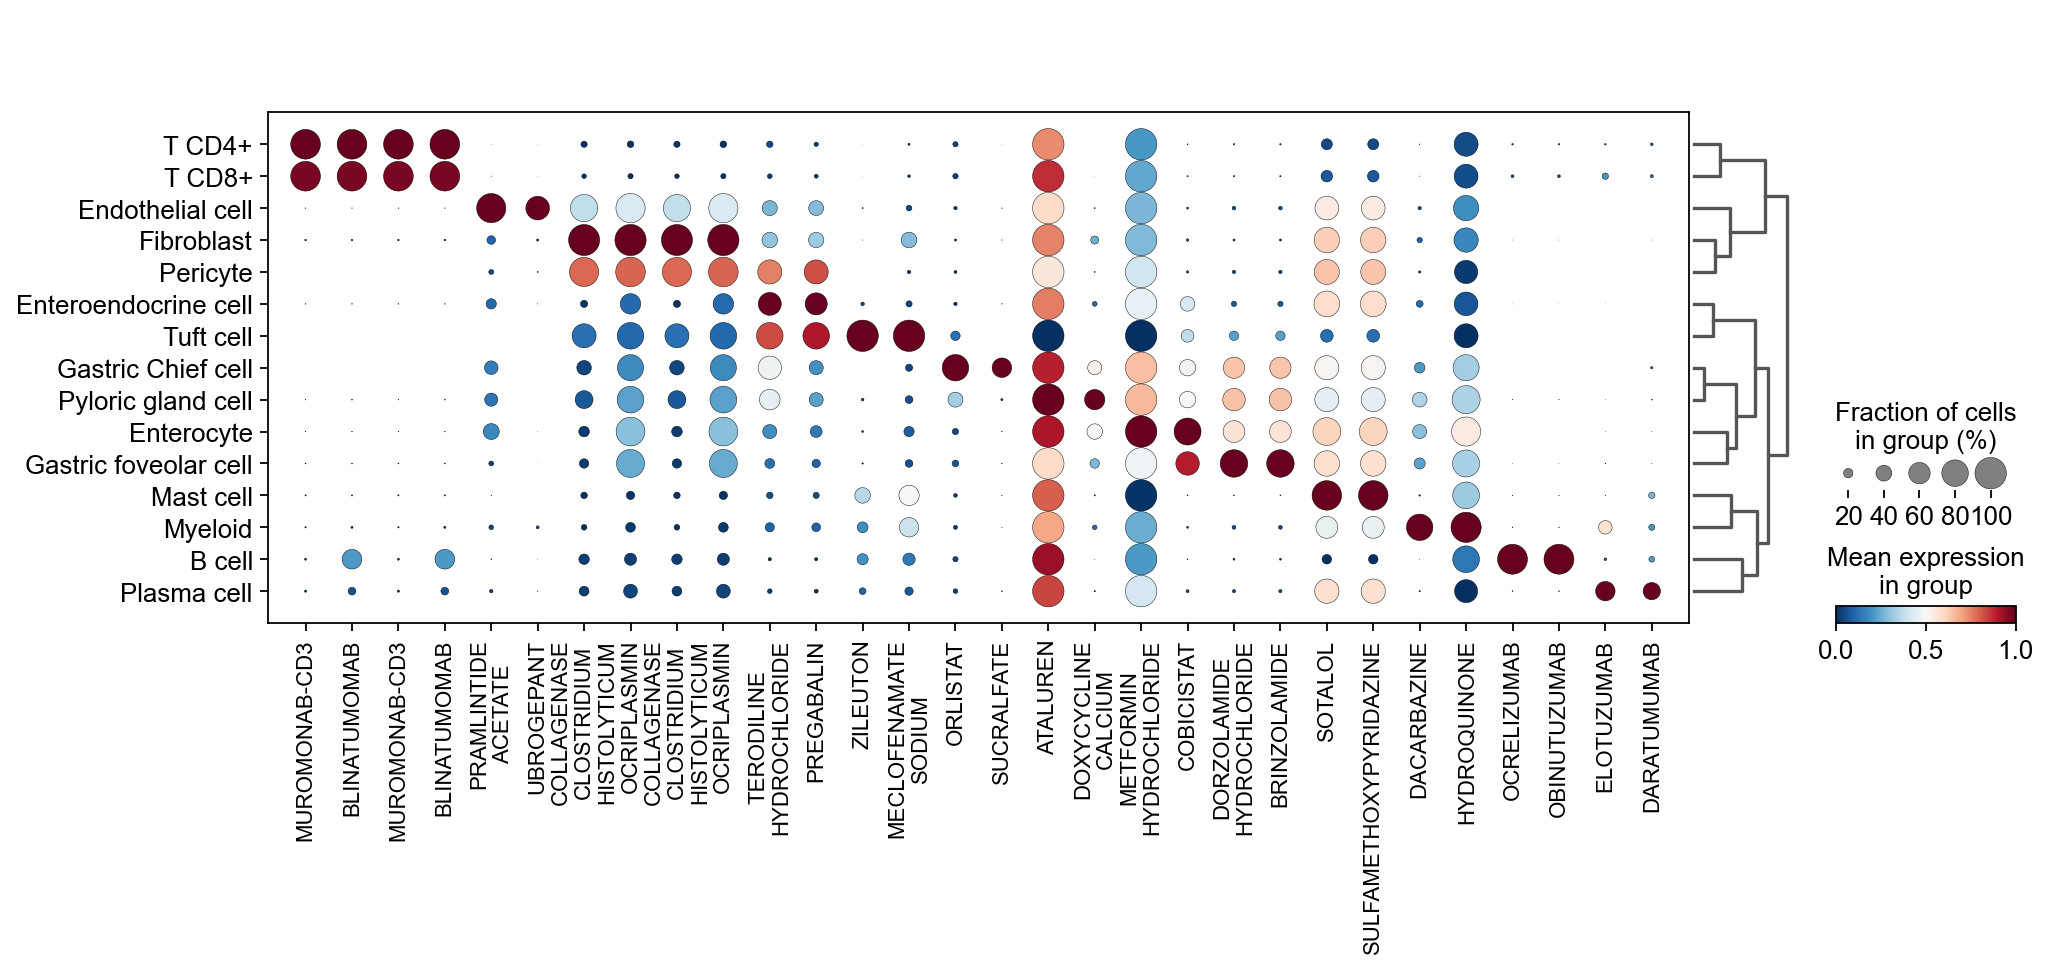

In [98]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14,5))
axes_dict=sc.pl.rank_genes_groups_dotplot(adata_drug,groupby='best_celltype',
                                cmap='RdBu_r',key='best_celltype_ttest',
                                standard_scale='var',n_genes=2,
                               ax=ax,show=False)
axes_dict['gene_group_ax'].set_visible(False)
# 为x轴标签着色
for label in axes_dict['mainplot_ax'].get_xticklabels():
    #label.set
    #label_text = label.get_text()
    label.set_size(10)
    #if label_text in gene_colors:
    # label.set_color(gene_colors[label_text])
plt.savefig(f'figures/drug/gc_drug_dot.png',dpi=300,bbox_inches='tight')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
**finished identifying marker genes by COSG**


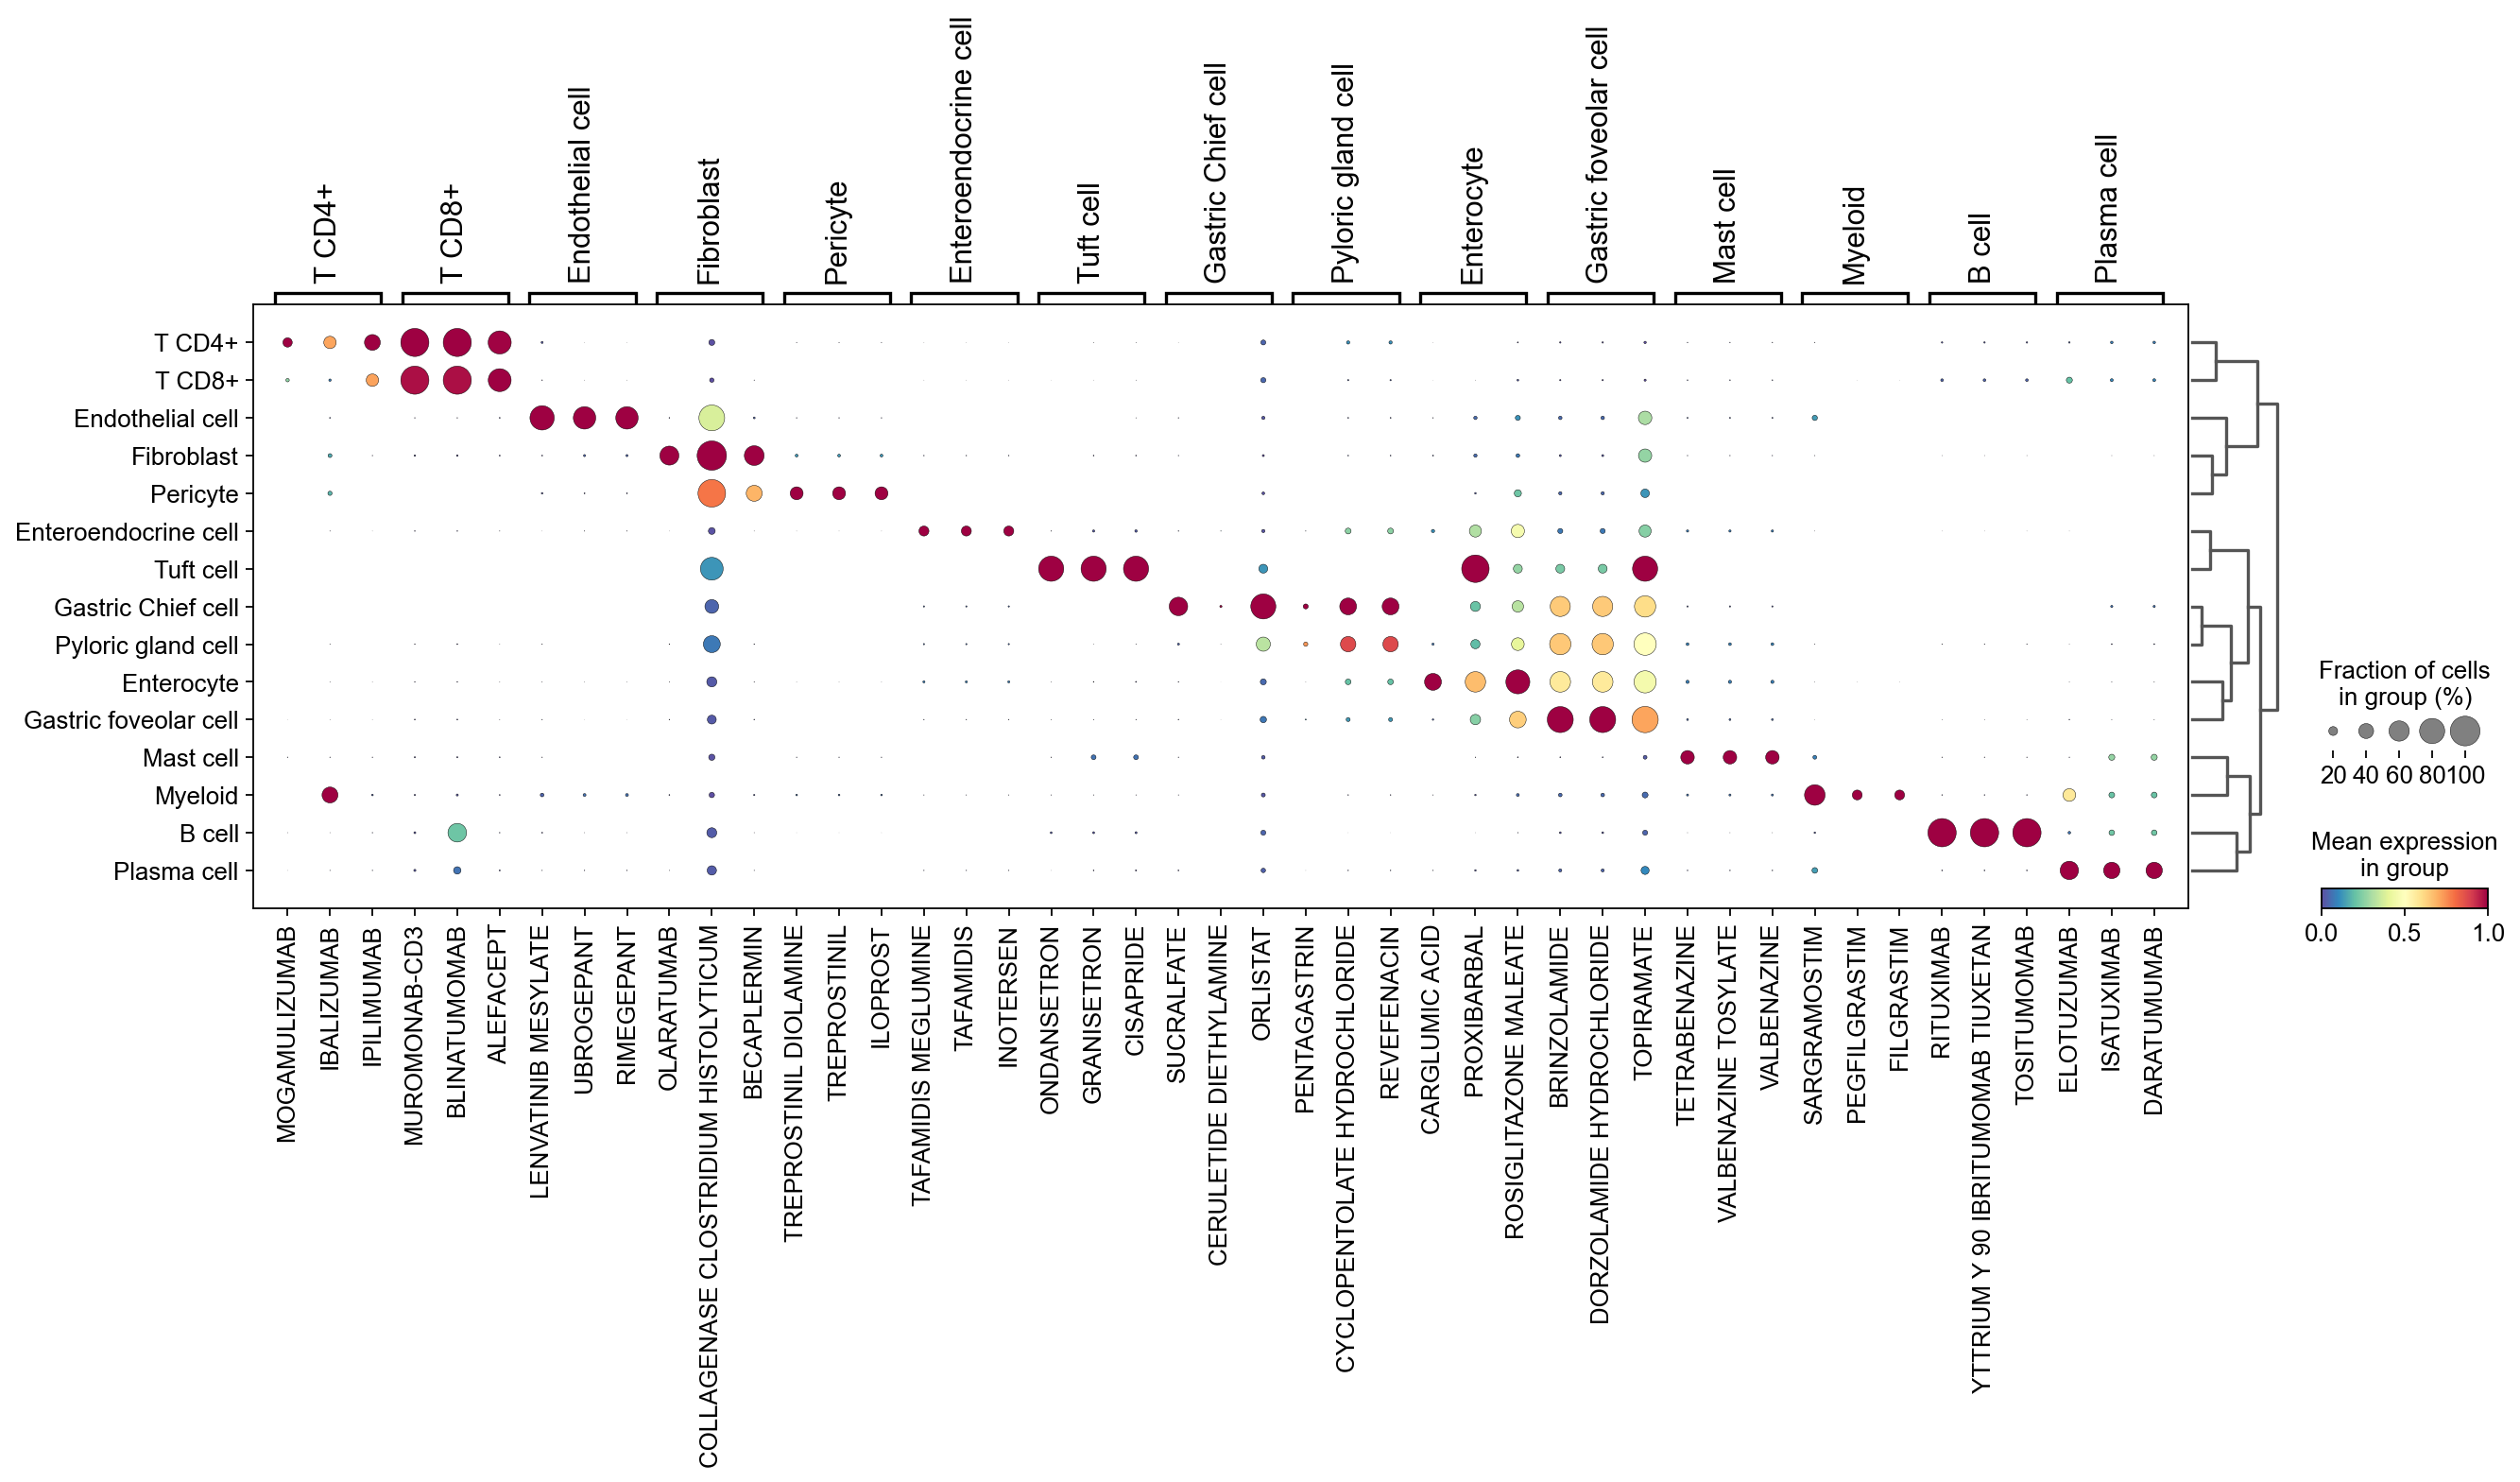

In [25]:
sc.tl.rank_genes_groups(adata_drug, groupby='best_celltype', 
                        method='t-test',use_rep='X_scVI',)
ov.single.cosg(adata_drug, key_added='best_celltype_cosg', groupby='best_celltype')
sc.pl.rank_genes_groups_dotplot(adata_drug,groupby='best_celltype',
                                cmap='Spectral_r',key='best_celltype_cosg',
                                standard_scale='var',n_genes=3)

In [26]:
adata_drug.layers['normalized']=adata_drug.X.copy()

In [27]:
def deg_clusters(adata,cluster_type,group_type,
                treatmentgroup,controlgroup,layer='normalized'):
    from tqdm import tqdm
    deg_results_dict={}
    adata.obs[cluster_type]=adata.obs[cluster_type].astype('category')
    for cluster in tqdm(adata.obs[cluster_type].cat.categories):
        adata_sub=adata[adata.obs[cluster_type]==cluster]
        test_adata=adata_sub
        dds=ov.bulk.pyDEG(test_adata.to_df(layer=layer).T)
        treatment_groups=test_adata.obs[test_adata.obs[group_type]==treatmentgroup].index.tolist()
        if len(treatment_groups)<=1:
            continue
        control_groups=test_adata.obs[test_adata.obs[group_type]==controlgroup].index.tolist()
        if len(control_groups)<=1:
            continue
        dds.result=dds.deg_analysis(treatment_groups,control_groups,method='ttest')
        dds.result=dds.result.loc[dds.result['BaseMean']>0.5]
        # -1 means automatically calculates
        dds.foldchange_set(fc_threshold=1,
                           pval_threshold=0.05,
                           logp_max=10)
        deg_results_dict[cluster]=dds.result
    adata.uns['deg_clusters_dict']=deg_results_dict
    return deg_results_dict
deg_results_dict=deg_clusters(adata=adata_drug,cluster_type='best_celltype',group_type='CancerStage',
                treatmentgroup='T1',controlgroup='No',layer='normalized')

  7%|▋         | 1/15 [00:00<00:01,  7.16it/s]

... Fold change threshold: 1
... Fold change threshold: 1


 40%|████      | 6/15 [00:00<00:00, 13.41it/s]

... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1


 73%|███████▎  | 11/15 [00:00<00:00, 17.99it/s]

... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1
... Fold change threshold: 1


100%|██████████| 15/15 [00:00<00:00, 15.45it/s]

... Fold change threshold: 1
... Fold change threshold: 1


In [45]:
marker_dict=ov.single.get_celltype_marker(adata_drug,clustertype='best_celltype',rank=False,
                                  key='best_celltype_ttest',method='t-test',
                                  scores_type='logfoldchanges',foldchange=1,
                                  topgenenumber=20)

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


In [46]:
from tqdm import tqdm
for cluster in tqdm(adata_drug.obs['best_celltype'].cat.categories):
    deg_cluster=cluster
    res=list(set(marker_dict[deg_cluster]) & set(deg_results_dict[deg_cluster].loc[deg_results_dict[deg_cluster]['sig']!='normal'].index))
    print(deg_cluster,res)

 93%|█████████▎| 14/15 [00:00<00:00, 3753.29it/s]

B cell ['ZALCITABINE', 'OFATUMUMAB', 'OBINUTUZUMAB', 'OCRELIZUMAB', 'RITUXIMAB', 'YTTRIUM Y 90 IBRITUMOMAB TIUXETAN', 'MOXETUMOMAB PASUDOTOX', 'IBRITUMOMAB TIUXETAN', 'TOSITUMOMAB', 'PLERIXAFOR']
Endothelial cell []
Enterocyte []
Enteroendocrine cell []
Fibroblast []
Gastric Chief cell ['SUCRALFATE']
Gastric foveolar cell ['METHYL NICOTINATE', 'METRONIDAZOLE', 'SODIUM NITRITE', 'VANCOMYCIN HYDROCHLORIDE', 'BERGAPTEN', 'ESCITALOPRAM', 'TIOPRONIN', 'NICORANDIL', 'NOSCAPINE']
Mast cell []
Myeloid []
Pericyte []
Plasma cell []
Pyloric gland cell ['METHSCOPOLAMINE BROMIDE', 'MEPENZOLATE BROMIDE', 'HEXOCYCLIUM METHYLSULFATE', 'PILOCARPINE', 'OXYPHENCYCLIMINE HYDROCHLORIDE', 'ACLIDINIUM BROMIDE', 'TRIDIHEXETHYL CHLORIDE', 'GLYCOPYRROLATE', 'CEVIMELINE HYDROCHLORIDE', 'REVEFENACIN', 'DICYCLOMINE HYDROCHLORIDE', 'ANISOTROPINE METHYLBROMIDE', 'DIPHEMANIL METHYLSULFATE', 'CYCLOPENTOLATE HYDROCHLORIDE', 'CLIDINIUM BROMIDE']
T CD4+ ['ZALCITABINE', 'PLERIXAFOR']
T CD8+ ['VEDOLIZUMAB', 'EFALIZUMAB', 

KeyError: 'Tuft cell'

In [103]:
deg_cluster='Gastric foveolar cell'
res=list(set(marker_dict[deg_cluster]) & set(deg_results_dict[deg_cluster].loc[deg_results_dict[deg_cluster]['sig']!='normal'].index))


In [108]:
ov.utils.plot_text_set(','.join(res))

'METHYL NICOTINATE,METRONIDAZOLE,SODIUM \n NITRITE,VANCOMYCIN HYDROCHLORIDE,BERGAPTEN,ESCITALOPRAM,TIOPRONIN,NICORANDIL,NOSCAPINE'

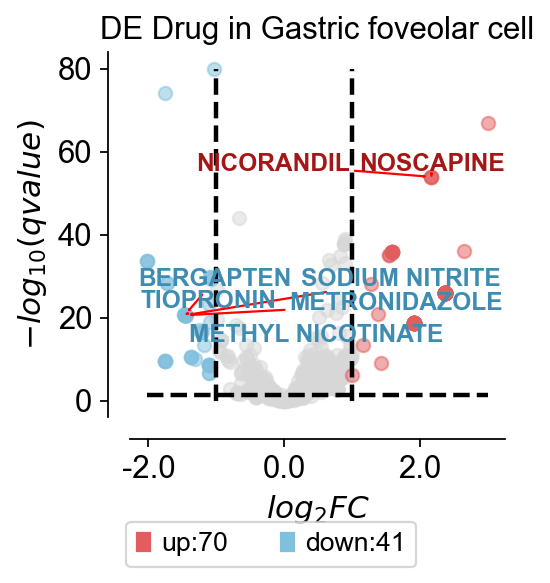

In [99]:
deg_cluster='Gastric foveolar cell'
ov.pl.volcano(deg_results_dict[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=1,fc_min=-1,
                      pval_max=80,FC_max=3,
                    figsize=(3,3),title=f'DE Drug in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['METHYL NICOTINATE', 'METRONIDAZOLE', 'SODIUM NITRITE', 
                                 #'VANCOMYCIN HYDROCHLORIDE', 
                                 'BERGAPTEN', 
                                 #'ESCITALOPRAM', 
                                 'TIOPRONIN', 'NICORANDIL', 'NOSCAPINE'],
                    #plot_genes_num=5,
                    plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/drug/vol_drug_{deg_cluster}.png',dpi=300,bbox_inches='tight')

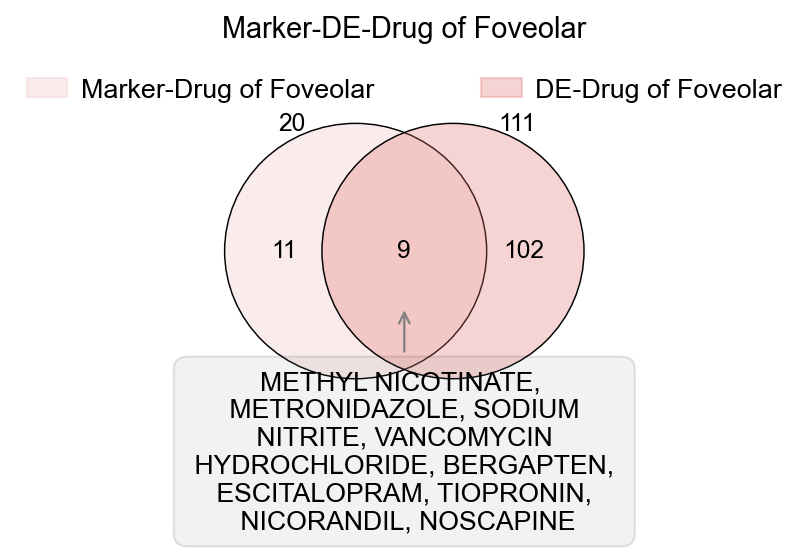

In [116]:
fig,ax=plt.subplots(figsize = (3,3))
#dict of sets
sets = {
    'Marker-Drug of Foveolar': set(marker_dict[deg_cluster]),
    'DE-Drug of Foveolar': set(deg_results_dict[deg_cluster].loc[deg_results_dict[deg_cluster]['sig']!='normal'].index),
}
    
ov.pl.venn(sets=sets,ax=ax,fontsize=5.5,
           palette=ov.pl.red_color)

plt.title('Marker-DE-Drug of Foveolar',fontsize=13)

plt.annotate(ov.utils.plot_text_set(', '.join(res)), xy=(50,30), xytext=(0,-100),
             ha='center', textcoords='offset points', 
             bbox=dict(boxstyle='round,pad=0.5', fc='gray', alpha=0.1),
             arrowprops=dict(arrowstyle='->', color='gray'),size=12)

plt.savefig(f'figures/drug/venn_drug_{deg_cluster}.png',dpi=300,bbox_inches='tight')

In [51]:
deg_results_dict[deg_cluster].loc['ESCITALOPRAM']

pvalue                  0.0
qvalue                  0.0
FoldChange         4.507284
MaxBaseMean        1.268529
BaseMean           0.774878
log2(BaseMean)    -0.367959
log2FC             2.172258
abs(log2FC)        2.172258
size               0.450728
-log(pvalue)      55.077803
-log(qvalue)           10.0
sig                      up
Name: ESCITALOPRAM, dtype: object

In [52]:
deg_results_dict[deg_cluster].loc['NOSCAPINE']

pvalue                  0.0
qvalue                  0.0
FoldChange         4.507284
MaxBaseMean        1.268529
BaseMean           0.774878
log2(BaseMean)    -0.367959
log2FC             2.172258
abs(log2FC)        2.172258
size               0.450728
-log(pvalue)      55.077803
-log(qvalue)           10.0
sig                      up
Name: NOSCAPINE, dtype: object

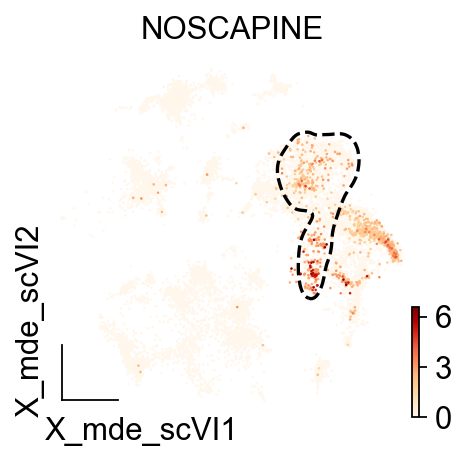

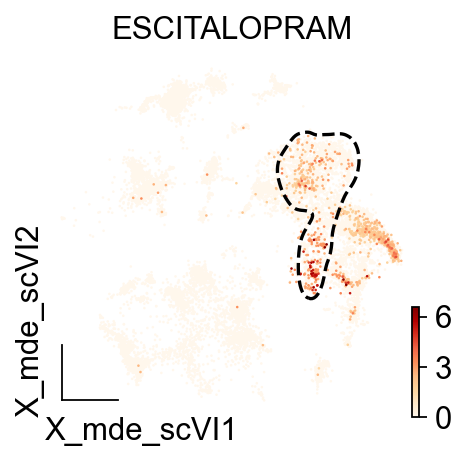

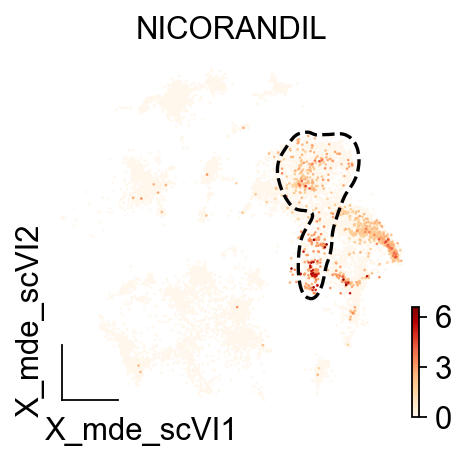

In [121]:
for drug in ['NOSCAPINE','ESCITALOPRAM','NICORANDIL']:
    fig,ax=plt.subplots(figsize = (3,3))
    ov.pl.embedding(adata_drug, 
                    basis='X_mde_scVI',
               color=drug, color_map="OrRd",
                   frameon='small',show=False,ax=ax)
    ov.pl.contour(ax=ax,adata=adata_drug,groupby='best_celltype',clusters=[deg_cluster],
       basis='X_mde_scVI',contour_threshold=0.1,colors='#000000',
        linestyles='dashed',)
    plt.savefig(f'figures/drug/emb_drug_{drug}-33.png',dpi=300,bbox_inches='tight')

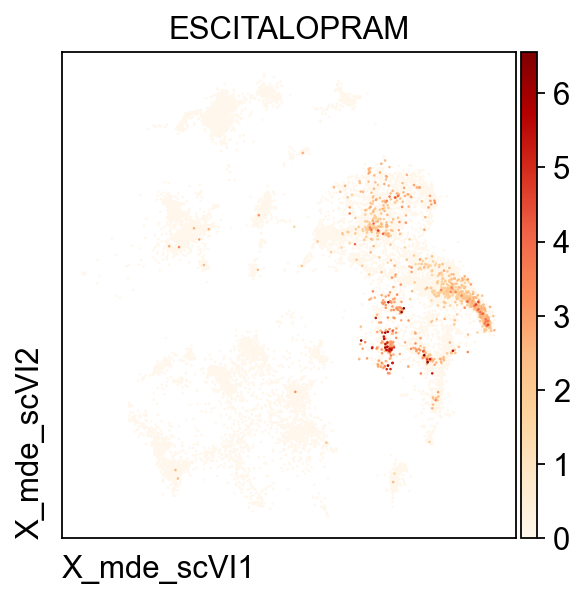

In [54]:
ov.pl.embedding(adata_drug, 
                basis='X_mde_scVI',
           color="ESCITALOPRAM", color_map="OrRd")


In [66]:
adata_drug.var.loc[['NOSCAPINE','ESCITALOPRAM','NICORANDIL']]

,genes,all_genes,drug_names,CHEMBL
NOSCAPINE,"CYP2C19,CYP2C9","CYP2C19,CYP2C9",NOSCAPINE,CHEMBL364713
ESCITALOPRAM,"CYP2C19,CYP2C9","CYP2C19,CYP2C9",ESCITALOPRAM,CHEMBL1508
NICORANDIL,"CYP2C19,CYP2C9","CYP2C19,CYP2C9",NICORANDIL,CHEMBL284906


In [57]:
adata.X.max()

15.946658

<AxesSubplot: title={'center': 'Group'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

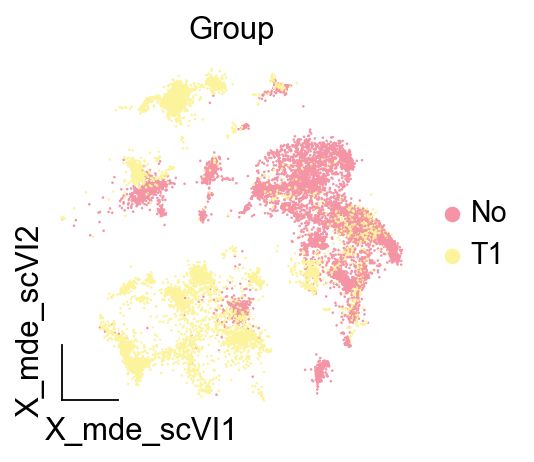

In [59]:
import matplotlib.pyplot as plt
fb=ov.pl.ForbiddenCity()
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['CancerStage'],
    title='Group',
    frameon='small',
    #ncols=1,
    palette=[
             fb.get_color(name='杨妃')['color_html'].values[0],
             fb.get_color(name='黄白游')['color_html'].values[0],],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

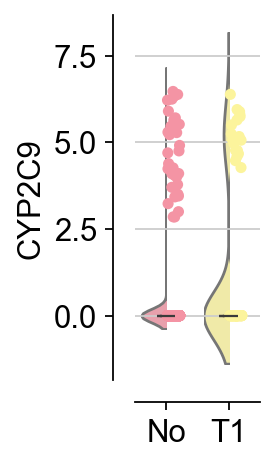

In [126]:
fig, ax = plt.subplots(1,1,figsize=(1,3))
ct='Gastric foveolar cell'
gene='CYP2C9'
violin_box(adata[adata.obs['best_celltype']==ct],gene,
                 groupby='CancerStage',ax=ax,show=False,
            #fontsize=14
                )
#ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
#                  text_y=0.1,
 #               text='$p={}$'.format(round(deg_results_dict_inflow[ct].loc[gene,'qvalue'],4)),
  #                fontsize=11,fontcolor='#000000',
 #                    horizontalalignment='center',)
plt.xlabel('')
plt.savefig(f'figures/drug/violin-signal-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')


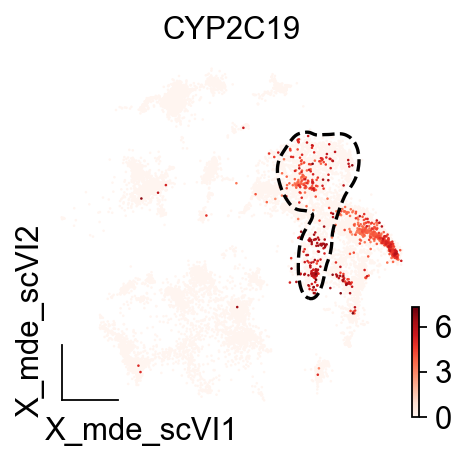

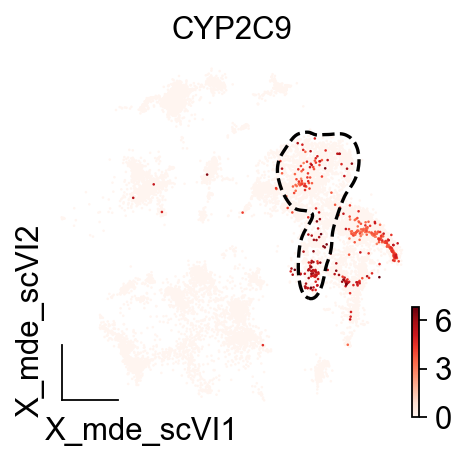

In [124]:
for drug in ['CYP2C19','CYP2C9']:
    fig,ax=plt.subplots(figsize = (3,3))
    ov.pl.embedding(adata, 
                    basis='X_mde_scVI',
               color=drug, color_map="Reds",
                   frameon='small',show=False,ax=ax)
    ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=[deg_cluster],
       basis='X_mde_scVI',contour_threshold=0.1,colors='#000000',
        linestyles='dashed',)
    plt.savefig(f'figures/drug/emb_gene_{drug}-33.png',dpi=300,bbox_inches='tight')